In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split,cross_val_score
from sklearn.metrics import accuracy_score,ConfusionMatrixDisplay
from sklearn.cluster import KMeans

In [ ]:
df=pd.read_csv('/content/Cust_Spend_Data.csv')

In [ ]:
df

,Cust_ID,Name,Avg_Mthly_Spend,No_Of_Visits,Apparel_Items,FnV_Items,Staples_Items
0,1,A,10000,2,1,1,0
1,2,B,7000,3,0,10,9
2,3,C,7000,7,1,3,4
3,4,D,6500,5,1,1,4
4,5,E,6000,6,0,12,3
5,6,F,4000,3,0,1,8
6,7,G,2500,5,0,11,2
7,8,H,2500,3,0,1,1
8,9,I,2000,2,0,2,2
9,10,J,1000,4,0,1,7


In [ ]:
df.columns


Index(['Cust_ID', 'Name', 'Avg_Mthly_Spend', 'No_Of_Visits', 'Apparel_Items',
       'FnV_Items', 'Staples_Items'],
      dtype='object')

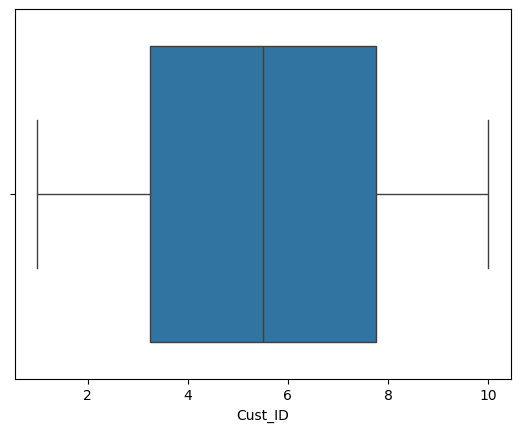

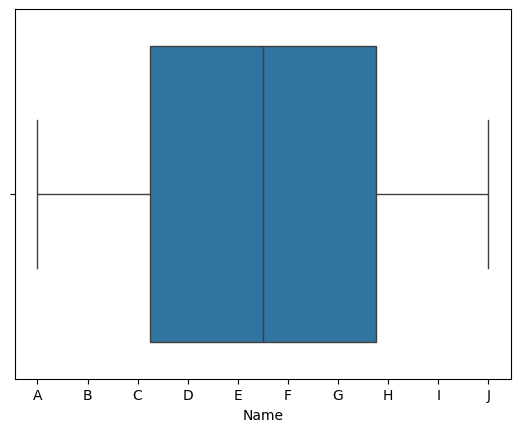

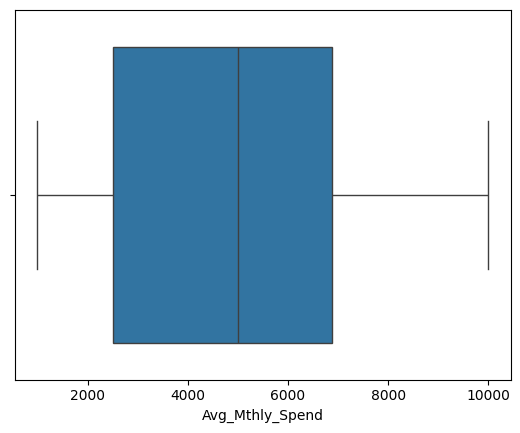

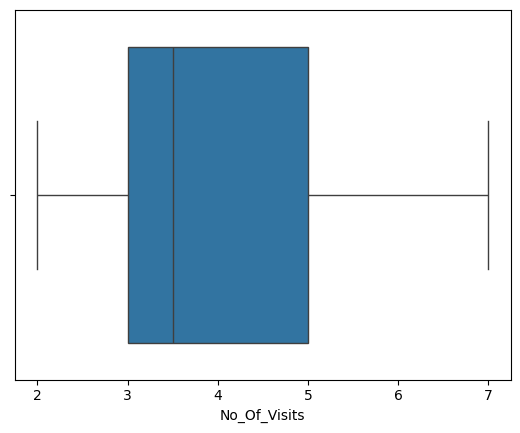

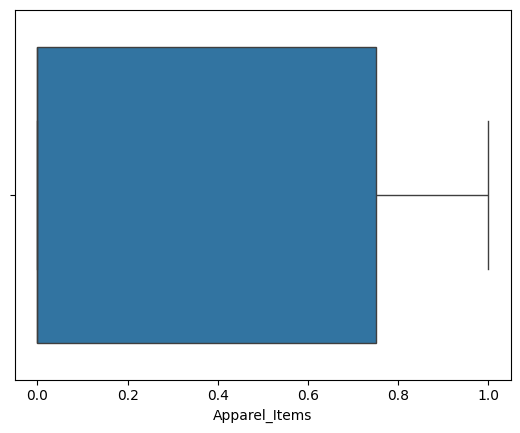

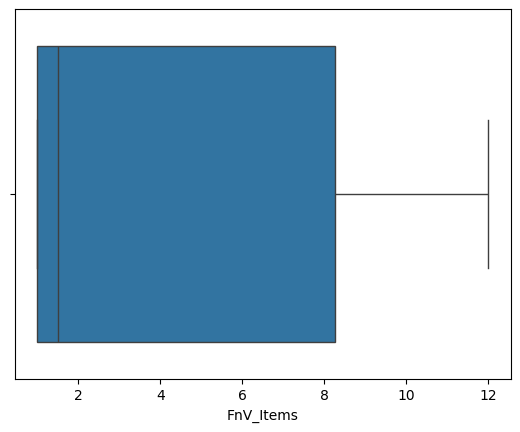

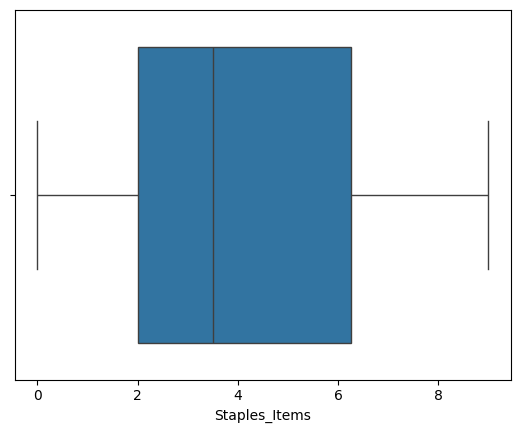

In [ ]:
for cols in df:
  sns.boxplot(df[cols],orient='h')
  plt.show()

In [ ]:
edata=df.iloc[:,2:]

In [ ]:
from sklearn.model_selection import train_test_split,cross_val_score

In [ ]:
std=StandardScaler()

In [ ]:
df=std.fit_transform(edata)

In [ ]:
df

array([[ 1.88649751, -1.24034735,  1.52752523, -0.74143264, -1.38013112],
       [ 0.78756692, -0.62017367, -0.65465367,  1.28065638,  1.7251639 ],
       [ 0.78756692,  1.86052102,  1.52752523, -0.29207953,  0.        ],
       [ 0.60441182,  0.62017367,  1.52752523, -0.74143264,  0.        ],
       [ 0.42125673,  1.24034735, -0.65465367,  1.7300095 , -0.34503278],
       [-0.31136367, -0.62017367, -0.65465367, -0.74143264,  1.38013112],
       [-0.86082896,  0.62017367, -0.65465367,  1.50533294, -0.69006556],
       [-0.86082896, -0.62017367, -0.65465367, -0.74143264, -1.03509834],
       [-1.04398406, -1.24034735, -0.65465367, -0.51675608, -0.69006556],
       [-1.41029426,  0.        , -0.65465367, -0.74143264,  1.03509834]])

In [ ]:
# selecting optimum number of cluster -> WCSS plot (Elbow graph)
wcss=[]
for i in range(1,10):
  kmeans=KMeans(n_clusters=i,init='k-means++',random_state=42,n_init='auto')
  kmeans.fit(edata)
  wcss.append(kmeans.inertia_)

In [ ]:
wcss

[74525310.2,
 14500293.600000001,
 5387740.75,
 2187714.5,
 854349.4166666667,
 291840.1666666666,
 125160.0,
 98.0,
 45.5]

In [ ]:
# init='k-means++ -> it will select the smart controids
# n_init -> run the loop and choose best number of cluster
# kmeans.inertia_ -> it will calculate the Wcss decrease as K Increase

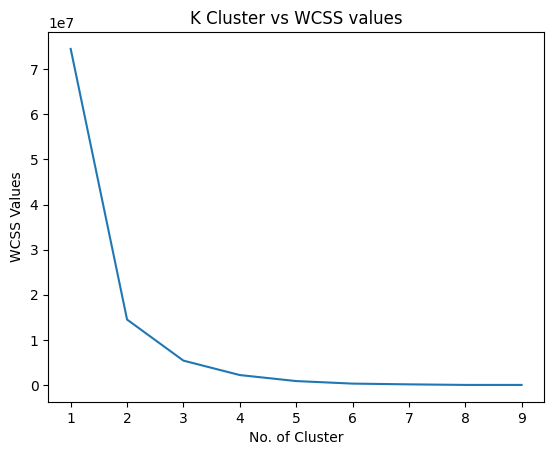

In [ ]:
plt.plot(range(1,10),wcss)
plt.xlabel("No. of Cluster")
plt.ylabel("WCSS Values")
plt.title("K Cluster vs WCSS values")
plt.show()